The first step is to load the required libaries

In [75]:
import urllib.request
import re
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

The next code here downloads the data needed.

In [76]:
url = (
    "https://raw.githubusercontent.com/rasbt/"
    "LLMs-from-scratch/main/ch02/01_main-chapter-code/"
    "the-verdict.txt"
)

file_path = "the-verdict.txt"

urllib.request.urlretrieve(url, file_path)

('the-verdict.txt', <http.client.HTTPMessage at 0x7c150abf8150>)

The code below reads and tokenize the data using regular expression

In [77]:
with open(file_path, "r", encoding="utf-8") as f:
    raw_text = f.read()

tokens = re.split(
    r'([,.:;?_!"()\']|--|\s)',
    raw_text
)

tokens = [
    token.strip()
    for token in tokens
    if token.strip()
]

The code below represents creating a vocabulary for the data availableto contain a token for every character and tokenid for each of them.

In [78]:
vocab = {
    token: i
    for i, token in enumerate(sorted(set(tokens)))
}

vocab_size = len(vocab)

token_ids = torch.tensor(
    [vocab[token] for token in tokens],
    dtype=torch.long
)

print("Vocabulary size:", vocab_size)
print("Number of tokens:", len(token_ids))

Vocabulary size: 1130
Number of tokens: 4690


Here we create a generative input and target token, where the input token will be trained to predict the target token during generation.

In [79]:
sequence_length = 100

input_ids = token_ids[:sequence_length]

target_ids = token_ids[1:sequence_length + 1]

Code below involved creating an embedding with 32 dimension and also an RNN layer for Model Training along with the 1D output layer

In [80]:
embedding_dim = 32
hidden_dim = 32

embedding = nn.Embedding(
    vocab_size,
    embedding_dim
)

rnn = nn.RNN(
    input_size=embedding_dim,
    hidden_size=hidden_dim,
    nonlinearity="tanh"
)

output_layer = nn.Linear(
    hidden_dim,
    vocab_size
)


In the code below we add the batch dimension.  to be passed into the model training loop, the extra dimension is important.

In [81]:
x = embedding(input_ids)

# Add batch dimension
x = x.unsqueeze(1)

x.shape
# [sequence_length, batch_size, embedding_dim]

torch.Size([100, 1, 32])

The Initial layers of the training will be initialized with zeros

In [82]:
h0 = torch.zeros(
    1,
    1,
    hidden_dim
)

we took one time step to show what we have in the output and hidden step.

In [83]:
output, hidden = rnn(
    x,
    h0
)

output

tensor([[[-0.3062,  0.4519, -0.5480,  ...,  0.2305,  0.6498, -0.4797]],

        [[-0.3322,  0.0921,  0.7254,  ..., -0.2160, -0.5017, -0.5466]],

        [[ 0.3114, -0.0531,  0.0069,  ...,  0.1019,  0.4217,  0.7597]],

        ...,

        [[ 0.3045, -0.2941,  0.1169,  ...,  0.3061, -0.1916,  0.3921]],

        [[-0.4207,  0.3236,  0.5788,  ..., -0.6582, -0.6436, -0.4780]],

        [[-0.5026,  0.4736, -0.0013,  ..., -0.1717, -0.2109,  0.6170]]],
       grad_fn=<StackBackward0>)

The code below involve computing the output predictions and making next token predictions

In [84]:
logits = output_layer(output)

# Remove batch dimension
logits = logits.squeeze(1)

print("Logits shape:", logits.shape)

Logits shape: torch.Size([100, 1130])


the code below computes the loss using cross entropy.

In [85]:
loss_function = nn.CrossEntropyLoss()

loss = loss_function(
    logits,
    target_ids
)

print("Loss:", loss.item())

Loss: 7.060085296630859


The code below computes backprop.

In [86]:
loss.backward()

In [87]:
print("\nGradient information:")

print(
    "RNN weight gradient:",
    rnn.weight_hh_l0.grad.norm().item()
)

print(
    "Embedding gradient:",
    embedding.weight.grad.norm().item()
)

print(
    "Output layer gradient:",
    output_layer.weight.grad.norm().item()
)


Gradient information:
RNN weight gradient: 0.14543788135051727
Embedding gradient: 0.027918938547372818
Output layer gradient: 0.30045944452285767


var below is the empty list for hidden state

In [88]:
hidden_states = []

The code below manually unrolls RNN to update the hidden state.

In [89]:
h = torch.zeros(hidden_dim,
                device=x.device)

for t in range(sequence_length):

    # Current token embedding
    x_t = x[t]

    # Keep track of previous hidden state
    h_previous = h

    # Manually perform the RNN calculation
    h = torch.tanh(
        x_t @ rnn.weight_ih_l0.T
        +
        h_previous @ rnn.weight_hh_l0.T
        +
        rnn.bias_ih_l0
        +
        rnn.bias_hh_l0
    )

    # Tell PyTorch to store gradient for this hidden state
    h.retain_grad()

    hidden_states.append(h)

The code below computes hidden state

In [90]:
hidden_stack = torch.stack(hidden_states).squeeze(1)

print("Hidden stack shape:", hidden_stack.shape)

logits = output_layer(hidden_stack)

print("Logits shape:", logits.shape)

# logits:
# [sequence_length, vocab_size]

loss_function = nn.CrossEntropyLoss()

loss = loss_function(
    logits,
    target_ids
)

print("Loss:", loss.item())

Hidden stack shape: torch.Size([100, 32])
Logits shape: torch.Size([100, 1130])
Loss: 7.060085296630859


The code below gets the gradient fromeach time step to be able to visualuse them as  they explode or vanish

In [91]:
gradient_norms = []

for t, h in enumerate(hidden_states):

    if h.grad is not None:
        gradient_norm = h.grad.norm().item()
    else:
        gradient_norm = 0.0

    gradient_norms.append(gradient_norm)

    print(
        f"Time step {t + 1}: "
        f"gradient = {gradient_norm:.10f}"
    )

Time step 1: gradient = 0.0000000000
Time step 2: gradient = 0.0000000000
Time step 3: gradient = 0.0000000000
Time step 4: gradient = 0.0000000000
Time step 5: gradient = 0.0000000000
Time step 6: gradient = 0.0000000000
Time step 7: gradient = 0.0000000000
Time step 8: gradient = 0.0000000000
Time step 9: gradient = 0.0000000000
Time step 10: gradient = 0.0000000000
Time step 11: gradient = 0.0000000000
Time step 12: gradient = 0.0000000000
Time step 13: gradient = 0.0000000000
Time step 14: gradient = 0.0000000000
Time step 15: gradient = 0.0000000000
Time step 16: gradient = 0.0000000000
Time step 17: gradient = 0.0000000000
Time step 18: gradient = 0.0000000000
Time step 19: gradient = 0.0000000000
Time step 20: gradient = 0.0000000000
Time step 21: gradient = 0.0000000000
Time step 22: gradient = 0.0000000000
Time step 23: gradient = 0.0000000000
Time step 24: gradient = 0.0000000000
Time step 25: gradient = 0.0000000000
Time step 26: gradient = 0.0000000000
Time step 27: gradien

The code below visualizes the Gradient magnitude with time steps

/tmp/ipykernel_1415/2816216091.py:12: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale("log")


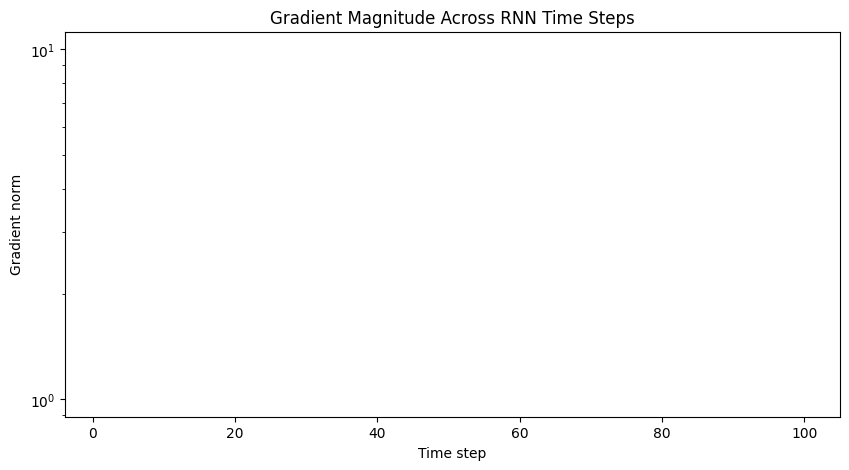

In [92]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, sequence_length + 1),
    gradient_norms
)

plt.xlabel("Time step")
plt.ylabel("Gradient norm")
plt.title("Gradient Magnitude Across RNN Time Steps")

plt.yscale("log")

plt.show()

Hidden states: torch.Size([100, 32])
Logits: torch.Size([100, 1130])
Loss: 7.011684417724609
Time step 1: gradient = 4.1653621010e-03
Time step 2: gradient = 6.5090083517e-03
Time step 3: gradient = 6.0364888050e-03
Time step 4: gradient = 7.3752473108e-03
Time step 5: gradient = 9.0666282922e-03
Time step 6: gradient = 7.4834907427e-03
Time step 7: gradient = 6.3571771607e-03
Time step 8: gradient = 7.8185833991e-03
Time step 9: gradient = 6.0987165198e-03
Time step 10: gradient = 5.9526027180e-03
Time step 11: gradient = 6.5439199097e-03
Time step 12: gradient = 5.3899260238e-03
Time step 13: gradient = 5.9263487346e-03
Time step 14: gradient = 6.5674497746e-03
Time step 15: gradient = 6.2414151616e-03
Time step 16: gradient = 6.9665629417e-03
Time step 17: gradient = 7.4896598235e-03
Time step 18: gradient = 5.8981128968e-03
Time step 19: gradient = 6.6102580167e-03
Time step 20: gradient = 5.3421631455e-03
Time step 21: gradient = 6.0598053969e-03
Time step 22: gradient = 6.4841257

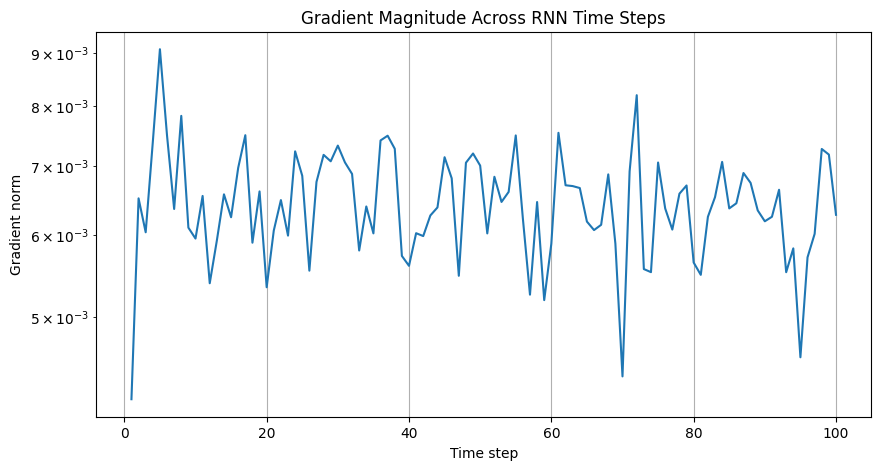

In [93]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


# ==========================================
# 1. SETTINGS
# ==========================================

torch.manual_seed(42)

sequence_length = 100
input_dim = 32
hidden_dim = 32
vocab_size = 1130


# ==========================================
# 2. CREATE FAKE EMBEDDINGS
# ==========================================
# We are using random embeddings here only
# to demonstrate the gradient problem.

x = torch.randn(
    sequence_length,
    input_dim
)


# ==========================================
# 3. RNN PARAMETERS
# ==========================================

W_x = nn.Parameter(
    torch.randn(hidden_dim, input_dim) * 0.1
)

W_h = nn.Parameter(
    torch.randn(hidden_dim, hidden_dim) * 0.1
)

b = nn.Parameter(
    torch.zeros(hidden_dim)
)


# ==========================================
# 4. OUTPUT LAYER
# ==========================================

W_out = nn.Parameter(
    torch.randn(vocab_size, hidden_dim) * 0.1
)

b_out = nn.Parameter(
    torch.zeros(vocab_size)
)


# ==========================================
# 5. INITIAL HIDDEN STATE
# ==========================================

h = torch.zeros(hidden_dim)


# ==========================================
# 6. MANUALLY RUN THE RNN
# ==========================================

hidden_states = []

for t in range(sequence_length):

    x_t = x[t]

    h = torch.tanh(
        W_x @ x_t
        +
        W_h @ h
        +
        b
    )

    # IMPORTANT
    # Keep gradient for this intermediate tensor
    h.retain_grad()

    hidden_states.append(h)


# ==========================================
# 7. FINAL OUTPUT
# ==========================================

# Stack all hidden states
hidden_stack = torch.stack(hidden_states)

print("Hidden states:", hidden_stack.shape)


# ==========================================
# 8. NEXT-TOKEN PREDICTION
# ==========================================

logits = (
    hidden_stack @ W_out.T
    +
    b_out
)

print("Logits:", logits.shape)


# ==========================================
# 9. RANDOM TARGET TOKENS
# ==========================================

target_ids = torch.randint(
    0,
    vocab_size,
    (sequence_length,)
)


# ==========================================
# 10. LOSS
# ==========================================

loss_function = nn.CrossEntropyLoss()

loss = loss_function(
    logits,
    target_ids
)

print("Loss:", loss.item())


# ==========================================
# 11. BACKPROPAGATION
# ==========================================

loss.backward()


# ==========================================
# 12. COLLECT GRADIENTS
# ==========================================

gradient_norms = []

for t, h in enumerate(hidden_states):

    gradient_norm = h.grad.norm().item()

    gradient_norms.append(
        gradient_norm
    )

    print(
        f"Time step {t + 1}: "
        f"gradient = {gradient_norm:.10e}"
    )


# ==========================================
# 13. PLOT
# ==========================================

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, sequence_length + 1),
    gradient_norms
)

plt.xlabel("Time step")
plt.ylabel("Gradient norm")

plt.title(
    "Gradient Magnitude Across RNN Time Steps"
)

plt.yscale("log")

plt.grid()

plt.show()